# 📈 Backtest — Carteira B3 | Estratégia EMA200 + CDB CDI

**Regras da estratégia:**
1. Aporte mensal dividido igualmente entre os ativos
2. Compra somente quando o preço está **abaixo da MME200** (gráfico diário)
3. Quando acima da MME200, o dinheiro fica em **CDB 100% CDI** de liquidez diária
4. Quando a ação volta abaixo da MME200, faz **preço médio diário** até esvaziar o caixa
5. Todo provento (dividendo/JCP) é **reinvestido** pelas mesmas regras acima

---

## 📦 Célula 1 — Instalação de dependências

In [ ]:
!pip install yfinance pandas numpy matplotlib requests -q
print("✅ Dependências instaladas com sucesso!")

✅ Dependências instaladas com sucesso!


## ⚙️ Célula 2 — Imports e configurações

> **Edite aqui:** troque os tickers, período, aporte mensal e demais parâmetros conforme sua estratégia.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import requests
import warnings
from pandas.tseries.offsets import DateOffset
warnings.filterwarnings("ignore")

# ──────────────────────────────────────────────
#  CONFIGURAÇÕES — altere aqui
# ──────────────────────────────────────────────

TICKERS        = ["ITSA4.SA", "TAEE11.SA", "BBAS3.SA", "VULC3.SA"]

# Dynamically set date range for the last 10 years from today
today_date = pd.to_datetime('today')
DATA_FIM       = today_date.strftime('%Y-%m-%d')
DATA_INICIO    = (today_date - DateOffset(years=10)).strftime('%Y-%m-%d')

APORTE_MENSAL  = 1000.0         # R$ aportado por mês no total

EMA_PERIODO    = 200            # períodos da Média Móvel Exponencial
TAXA_CDB       = 1.00           # % do CDI (1.00 = 100% CDI)

# Fração do caixa de cada ativo investida por dia
# quando o preço está abaixo da MME200.
# 1/20 ≈ 1 mês de pregões → simula o preço médio gradual
DEPLOY_DIARIO  = 1 / 20

# ──────────────────────────────────────────────

print(f"Tickers    : {', '.join(TICKERS)}")
print(f"Período    : {DATA_INICIO} → {DATA_FIM}")
print(f"Aporte     : R$ {APORTE_MENSAL:,.2f}/mês")
print(f"CDB CDI    : {TAXA_CDB*100:.0f}%  |  Deploy diário: {DEPLOY_DIARIO:.1%} do caixa")
print("✅ Configurações carregadas!")

Tickers    : ITSA4.SA, TAEE11.SA, BBAS3.SA, VULC3.SA
Período    : 2016-04-21 → 2026-04-21
Aporte     : R$ 1,000.00/mês
CDB CDI    : 100%  |  Deploy diário: 5.0% do caixa
✅ Configurações carregadas!


## 📡 Célula 3 — Coleta de cotações e proventos (yfinance)

In [ ]:
print("Baixando cotações e proventos via yfinance...\n")

raw = yf.download(
    TICKERS,
    start=DATA_INICIO,
    end=DATA_FIM,
    auto_adjust=False,
    actions=True,
    progress=True,
    group_by="ticker"
)

precos_dict   = {}
proventos_dict = {}

for tk in TICKERS:
    try:
        if len(TICKERS) == 1:
            preco = raw["Close"]
            div   = raw["Dividends"]
        else:
            preco = raw[tk]["Close"]
            div   = raw[tk]["Dividends"]

        preco = preco.dropna()
        div   = div[div > 0]

        precos_dict[tk]    = preco
        proventos_dict[tk] = div

        print(f"  {tk}: {len(preco)} pregões | {len(div)} eventos de provento")
    except Exception as e:
        print(f"  ERRO ao processar {tk}: {e}")

df_precos    = pd.DataFrame(precos_dict).ffill()
df_proventos = pd.DataFrame(proventos_dict).fillna(0)
df_proventos = df_proventos.reindex(df_precos.index, fill_value=0)

print("\n✅ Dados carregados!")
print(f"   Período efetivo: {df_precos.index[0].date()} → {df_precos.index[-1].date()}")
print(f"   Total de pregões: {len(df_precos)}")
df_precos.tail(3)

[**********************50%                       ]  2 of 4 completed

Baixando cotações e proventos via yfinance...



[*********************100%***********************]  4 of 4 completed

  ITSA4.SA: 2491 pregões | 82 eventos de provento
  TAEE11.SA: 2491 pregões | 42 eventos de provento
  BBAS3.SA: 2491 pregões | 72 eventos de provento
  VULC3.SA: 2491 pregões | 31 eventos de provento

✅ Dados carregados!
   Período efetivo: 2016-04-22 → 2026-04-20
   Total de pregões: 2491


,ITSA4.SA,TAEE11.SA,BBAS3.SA,VULC3.SA
Date,,,,
2026-04-16,14.81,44.299999,24.280001,17.100000
2026-04-17,14.81,45.009998,24.400000,17.299999
2026-04-20,14.74,45.860001,24.280001,17.219999


## 🏦 Célula 4 — Coleta da taxa CDI diária (API do BCB)

In [ ]:
def buscar_serie_bcb(serie_id: int, inicio: str, fim: str, nome: str) -> "pd.Series":
    """Busca série diária do BCB. Série 12 = CDI | Série 11 = SELIC (% ao dia)."""
    url = (
        f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.{serie_id}/dados"
        f"?formato=json"
        f"&dataInicial={pd.to_datetime(inicio).strftime('%d/%m/%Y')}"
    )
    try:
        resp = requests.get(url, timeout=15)
        resp.raise_for_status()
        df = pd.DataFrame(resp.json())
        df["data"]  = pd.to_datetime(df["data"], dayfirst=True)
        df["valor"] = pd.to_numeric(df["valor"]) / 100   # % → decimal diária
        df = df.set_index("data")["valor"]
        print(f"  ✅ {nome}: {len(df)} dias úteis")
        return df
    except Exception as e:
        print(f"  ⚠️  {nome} falhou ({e}) — usando fallback 13,65% a.a.")
        datas = pd.bdate_range(inicio, fim)
        taxa_ad = (1 + 0.1365) ** (1 / 252) - 1
        return pd.Series(taxa_ad, index=datas)


print("Buscando taxas de referência no Banco Central do Brasil...\n")

# Série 12 = CDI | Série 11 = SELIC
cdi_raw   = buscar_serie_bcb(12, DATA_INICIO, DATA_FIM, "CDI  ")
selic_raw = buscar_serie_bcb(11, DATA_INICIO, DATA_FIM, "SELIC")

# Alinha ao calendário de pregões das ações
cdi_diario   = cdi_raw.reindex(df_precos.index).ffill().fillna(0)
selic_diario = selic_raw.reindex(df_precos.index).ffill().fillna(0)

cdi_anual_medio   = ((1 + cdi_diario.mean())   ** 252 - 1) * 100
selic_anual_medio = ((1 + selic_diario.mean()) ** 252 - 1) * 100

print(f"\n  CDI médio do período  : {cdi_anual_medio:.2f}% a.a.")
print(f"  SELIC média do período: {selic_anual_medio:.2f}% a.a.")

pd.DataFrame({"CDI (a.d.)": cdi_diario, "SELIC (a.d.)": selic_diario}).head(5)


Buscando taxas de referência no Banco Central do Brasil...

  ✅ CDI  : 2509 dias úteis
  ✅ SELIC: 2509 dias úteis

  CDI médio do período  : 9.41% a.a.
  SELIC média do período: 9.41% a.a.


,CDI (a.d.),SELIC (a.d.)
Date,,
2016-04-22,0.000525,0.000525
2016-04-25,0.000525,0.000525
2016-04-26,0.000525,0.000525
2016-04-27,0.000525,0.000525
2016-04-28,0.000525,0.000525


## 📉 Célula 4b — Coleta do IBOVESPA (benchmark)

In [ ]:
print("Baixando IBOVESPA (^BVSP)...")

ibov_raw = yf.download(
    "^BVSP",
    start=DATA_INICIO,
    end=DATA_FIM,
    auto_adjust=True,
    progress=False
)["Close"].squeeze().dropna()

# Alinha ao calendário de pregões das ações brasileiras
ibov_diario = ibov_raw.reindex(df_precos.index).ffill()

retorno_ibov_total = (ibov_diario.iloc[-1] / ibov_diario.iloc[0] - 1) * 100

print(f"  ✅ IBOVESPA carregado: {len(ibov_diario)} pregões")
print(f"     Abertura: {ibov_diario.iloc[0]:,.0f} pts  →  Fechamento: {ibov_diario.iloc[-1]:,.0f} pts")
ibov_diario.tail(3).rename("IBOVESPA (pts)").to_frame()


Baixando IBOVESPA (^BVSP)...
  ✅ IBOVESPA carregado: 2491 pregões
     Abertura: 52,908 pts  →  Fechamento: 196,132 pts


,IBOVESPA (pts)
Date,
2026-04-16,196819.0
2026-04-17,195734.0
2026-04-20,196132.0


## 📊 Célula 5 — Cálculo da MME200 para cada ativo

Média Móvel Exponencial de 200 períodos calculada.

  Ativo       | % do tempo ABAIXO da MME200 (elegível p/ compra)
  -------------------------------------------------------
  ITSA4.SA    | 33.2%
  TAEE11.SA   | 40.3%
  BBAS3.SA    | 40.1%
  VULC3.SA    | 31.7%

✅ MME200 calculada para todos os ativos!


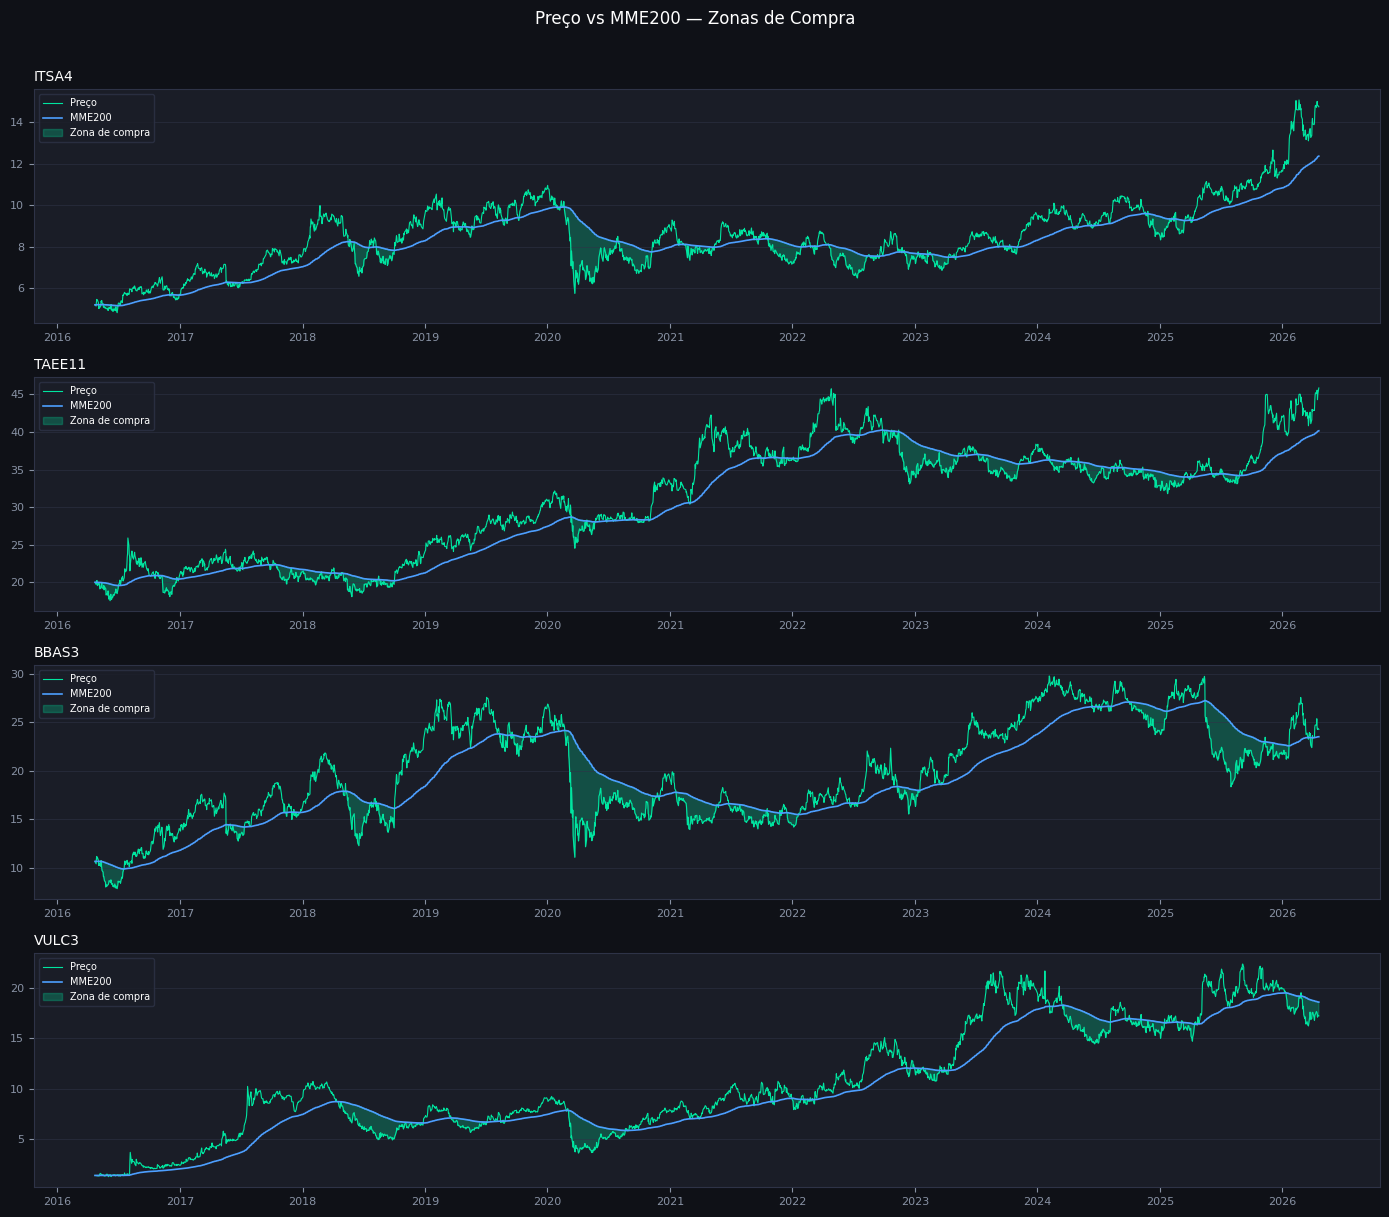

In [ ]:
def calcular_ema(serie, periodo):
    """EMA padrão (igual TradingView / MetaTrader)."""
    return serie.ewm(span=periodo, adjust=False).mean()


ema = {}
for tk in TICKERS:
    ema[tk] = calcular_ema(df_precos[tk], EMA_PERIODO)

df_ema = pd.DataFrame(ema)

# Visualização: quantos % do tempo cada ativo ficou abaixo da MME200
print(f"Média Móvel Exponencial de {EMA_PERIODO} períodos calculada.\n")
print("  Ativo       | % do tempo ABAIXO da MME200 (elegível p/ compra)")
print("  " + "-"*55)
for tk in TICKERS:
    abaixo = (df_precos[tk] < df_ema[tk]).mean() * 100
    print(f"  {tk:<12}| {abaixo:.1f}%")

print("\n✅ MME200 calculada para todos os ativos!")

# Mini-gráfico de confirmação
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(14, 3 * len(TICKERS)),
                          facecolor="#0f1117")
VERDE, AZUL, CINZA = "#00e5a0", "#4d9fff", "#8892a4"

for i, tk in enumerate(TICKERS):
    ax = axes[i] if len(TICKERS) > 1 else axes
    ax.set_facecolor("#1a1d27")
    ax.tick_params(colors=CINZA, labelsize=8)
    ax.spines[:].set_color("#2e3347")

    ax.plot(df_precos.index, df_precos[tk], color=VERDE, lw=0.8,
            label="Preço")
    ax.plot(df_ema.index, df_ema[tk], color=AZUL, lw=1.2,
            label=f"MME{EMA_PERIODO}")

    # Área abaixo da MME (zona de compra)
    ax.fill_between(df_precos.index,
                    df_precos[tk], df_ema[tk],
                    where=(df_precos[tk] < df_ema[tk]),
                    alpha=0.25, color=VERDE, label="Zona de compra")

    nome = tk.replace(".SA", "")
    ax.set_title(nome, color="white", fontsize=10, loc="left")
    ax.legend(facecolor="#1a1d27", labelcolor="white",
              fontsize=7, edgecolor="#2e3347")
    ax.grid(axis="y", color="#2e3347", lw=0.4)

plt.suptitle(f"Preço vs MME{EMA_PERIODO} — Zonas de Compra",
             color="white", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## ⚙️ Célula 6 — Motor do backtest (simulação diária)

> Esta é a célula principal. Aqui roda a simulação dia a dia para todos os ativos.

In [ ]:
dias_pregao      = df_precos.index
n_ativos         = len(TICKERS)
aporte_por_ativo = APORTE_MENSAL / n_ativos

# ── Estado inicial da carteira ────────────────────────────────
cotas  = {tk: 0.0 for tk in TICKERS}  # quantidade de ações
caixa  = {tk: 0.0 for tk in TICKERS}  # R$ reservado por ativo (CDB)

# ── Histórico diário ──────────────────────────────────────────
hist = {
    "data"           : [],
    "patrimonio"     : [],
    "acoes"          : [],
    "cdb"            : [],
    "aportado_total" : [],
}

total_aportado = 0.0
ultimo_mes     = -1
prov_total     = {tk: 0.0 for tk in TICKERS}

# ── Estado dos benchmarks ─────────────────────────────────────
bm_cdi_cx   = 0.0;  bm_cdi_mes   = -1;  bm_cdi_tot   = []
bm_sel_cx   = 0.0;  bm_sel_mes   = -1;  bm_sel_tot   = []
bm_ibov_cot = 0.0;  bm_ibov_mes  = -1;  bm_ibov_tot  = []

print(f"Simulando {len(dias_pregao)} pregões ({DATA_INICIO} → {DATA_FIM})...\n")

for data in dias_pregao:

    # ── Aporte mensal (1º pregão do mês) ─────────────────────
    if data.month != ultimo_mes:
        for tk in TICKERS:
            caixa[tk] += aporte_por_ativo
        total_aportado += APORTE_MENSAL
        ultimo_mes = data.month

    # ── Processamento por ativo ───────────────────────────────
    for tk in TICKERS:
        preco  = df_precos.loc[data, tk]
        mme    = df_ema[tk].loc[data]
        taxa_d = cdi_diario.loc[data] * TAXA_CDB

        if pd.isna(preco) or pd.isna(mme) or preco <= 0:
            caixa[tk] *= (1 + taxa_d)
            continue

        # ── Proventos recebidos no dia ────────────────────────
        if tk in df_proventos.columns:
            div_por_acao = df_proventos.loc[data, tk]
            if div_por_acao > 0:
                recebido = cotas[tk] * div_por_acao
                caixa[tk]     += recebido
                prov_total[tk] += recebido

        # ── Decisão de compra ou CDI ──────────────────────────
        if preco < mme:
            valor_compra = min(caixa[tk] * DEPLOY_DIARIO, caixa[tk])
            if valor_compra > 0.01:
                cotas[tk]  += valor_compra / preco
                caixa[tk]  -= valor_compra
            caixa[tk] *= (1 + taxa_d)
        else:
            caixa[tk] *= (1 + taxa_d)

    # ── Snapshot patrimonial ──────────────────────────────────
    valor_acoes = sum(
        cotas[tk] * df_precos.loc[data, tk]
        for tk in TICKERS if not pd.isna(df_precos.loc[data, tk])
    )
    valor_cdb  = sum(caixa[tk] for tk in TICKERS)

    hist["data"].append(data)
    hist["patrimonio"].append(valor_acoes + valor_cdb)
    hist["acoes"].append(valor_acoes)
    hist["cdb"].append(valor_cdb)
    hist["aportado_total"].append(total_aportado)

    # ── Benchmark CDI ─────────────────────────────────────────
    if data.month != bm_cdi_mes:
        bm_cdi_cx  += APORTE_MENSAL
        bm_cdi_mes  = data.month
    bm_cdi_cx *= (1 + cdi_diario.loc[data] * TAXA_CDB)
    bm_cdi_tot.append(bm_cdi_cx)

    # ── Benchmark SELIC ───────────────────────────────────────
    if data.month != bm_sel_mes:
        bm_sel_cx  += APORTE_MENSAL
        bm_sel_mes  = data.month
    bm_sel_cx *= (1 + selic_diario.loc[data])
    bm_sel_tot.append(bm_sel_cx)

    # ── Benchmark IBOVESPA ────────────────────────────────────
    # Compra cotas do índice no 1º pregão do mês
    preco_ibov = ibov_diario.loc[data] if data in ibov_diario.index else np.nan
    if data.month != bm_ibov_mes and not pd.isna(preco_ibov) and preco_ibov > 0:
        bm_ibov_cot += APORTE_MENSAL / preco_ibov
        bm_ibov_mes  = data.month
    val_ibov = bm_ibov_cot * preco_ibov if not pd.isna(preco_ibov) else (bm_ibov_tot[-1] if bm_ibov_tot else 0)
    bm_ibov_tot.append(val_ibov)


df_hist = pd.DataFrame(hist).set_index("data")
df_hist["benchmark_cdi"]   = bm_cdi_tot
df_hist["benchmark_selic"] = bm_sel_tot
df_hist["benchmark_ibov"]  = bm_ibov_tot

print("✅ Simulação concluída!")
print(f"   Pregões processados : {len(df_hist)}")
print(f"   Total aportado      : R$ {total_aportado:,.2f}")
print(f"   Patrimônio final    : R$ {df_hist['patrimonio'].iloc[-1]:,.2f}")
df_hist.tail(3)


Simulando 2491 pregões (2016-04-21 → 2026-04-21)...

✅ Simulação concluída!
   Pregões processados : 2491
   Total aportado      : R$ 121,000.00
   Patrimônio final    : R$ 346,864.51


,patrimonio,acoes,cdb,aportado_total,benchmark_cdi,benchmark_selic,benchmark_ibov
data,,,,,,,
2026-04-16,343705.317317,323988.229567,19717.087751,121000.0,202400.032166,202409.701744,247297.179929
2026-04-17,346542.792203,326880.182567,19662.609636,121000.0,202509.866568,202519.541393,245933.909918
2026-04-20,346864.514668,327253.187421,19611.327247,121000.0,202619.760572,202629.440647,246433.985000


## 📋 Célula 7 — Métricas de desempenho

In [ ]:
pat_final      = df_hist["patrimonio"].iloc[-1]
bm_cdi_final   = df_hist["benchmark_cdi"].iloc[-1]
bm_sel_final   = df_hist["benchmark_selic"].iloc[-1]
bm_ibov_final  = df_hist["benchmark_ibov"].iloc[-1]
n_anos         = len(df_hist) / 252

retorno_total  = (pat_final / total_aportado - 1) * 100
cagr_cart      = ((pat_final     / total_aportado) ** (1 / n_anos) - 1) * 100
cagr_bm        = ((bm_cdi_final  / total_aportado) ** (1 / n_anos) - 1) * 100
cagr_selic     = ((bm_sel_final  / total_aportado) ** (1 / n_anos) - 1) * 100
cagr_ibov      = ((bm_ibov_final / total_aportado) ** (1 / n_anos) - 1) * 100

# Manter alias para compatibilidade com outras células
bm_final = bm_cdi_final

rolling_max   = df_hist["patrimonio"].cummax()
drawdown_d    = (df_hist["patrimonio"] - rolling_max) / rolling_max * 100
max_dd        = drawdown_d.min()

retornos_d    = df_hist["patrimonio"].pct_change().dropna()
vol_anual     = retornos_d.std() * np.sqrt(252) * 100

# Sharpe (CDI como taxa livre de risco)
rf_anual   = cagr_bm / 100
rf_diario  = (1 + rf_anual) ** (1 / 252) - 1
sharpe     = (retornos_d.mean() - rf_diario) / retornos_d.std() * np.sqrt(252)

prov_total_geral = sum(prov_total[tk] for tk in TICKERS)

metricas = {
    "cagr_cart": cagr_cart, "cagr_bm": cagr_bm,
    "cagr_selic": cagr_selic, "cagr_ibov": cagr_ibov,
    "max_dd": max_dd, "vol_anual": vol_anual, "pat_final": pat_final
}

linhas = [
    ("Total aportado",             f"R$ {total_aportado:>15,.2f}"),
    ("Patrimônio final",           f"R$ {pat_final:>15,.2f}"),
    ("Lucro líquido",              f"R$ {pat_final - total_aportado:>15,.2f}"),
    ("-"*32,                       "-"*22),
    ("Retorno total",              f"{retorno_total:>16.1f}%"),
    ("CAGR carteira",              f"{cagr_cart:>16.2f}% a.a."),
    ("-"*32,                       "-"*22),
    ("CAGR benchmark CDI",         f"{cagr_bm:>16.2f}% a.a."),
    ("CAGR benchmark SELIC",       f"{cagr_selic:>16.2f}% a.a."),
    ("CAGR benchmark IBOVESPA",    f"{cagr_ibov:>16.2f}% a.a."),
    ("-"*32,                       "-"*22),
    ("Alpha vs CDI",               f"{cagr_cart - cagr_bm:>+16.2f}% a.a."),
    ("Alpha vs SELIC",             f"{cagr_cart - cagr_selic:>+16.2f}% a.a."),
    ("Alpha vs IBOVESPA",          f"{cagr_cart - cagr_ibov:>+16.2f}% a.a."),
    ("-"*32,                       "-"*22),
    ("Drawdown máximo",            f"{max_dd:>16.2f}%"),
    ("Volatilidade anualizada",    f"{vol_anual:>16.2f}%"),
    ("Índice de Sharpe",           f"{sharpe:>16.2f}"),
    ("-"*32,                       "-"*22),
    ("Proventos reinvestidos",     f"R$ {prov_total_geral:>15,.2f}"),
    ("Benchmark CDI final",        f"R$ {bm_cdi_final:>15,.2f}"),
    ("Benchmark SELIC final",      f"R$ {bm_sel_final:>15,.2f}"),
    ("Benchmark IBOVESPA final",   f"R$ {bm_ibov_final:>15,.2f}"),
]

print("\n" + "═"*58)
print("  RESULTADOS DO BACKTEST")
print("═"*58)
for k, v in linhas:
    print(f"  {k:<32} {v}")
print("═"*58)



══════════════════════════════════════════════════════════
  RESULTADOS DO BACKTEST
══════════════════════════════════════════════════════════
  Total aportado                   R$      121,000.00
  Patrimônio final                 R$      346,864.51
  Lucro líquido                    R$      225,864.51
  -------------------------------- ----------------------
  Retorno total                               186.7%
  CAGR carteira                               11.24% a.a.
  -------------------------------- ----------------------
  CAGR benchmark CDI                           5.35% a.a.
  CAGR benchmark SELIC                         5.35% a.a.
  CAGR benchmark IBOVESPA                      7.46% a.a.
  -------------------------------- ----------------------
  Alpha vs CDI                                +5.89% a.a.
  Alpha vs SELIC                              +5.89% a.a.
  Alpha vs IBOVESPA                           +3.78% a.a.
  -------------------------------- ----------------------
  D

## 📊 Célula 7b — Dashboard Interativo de Métricas

> Visualização completa dos resultados com gráficos interativos e comparação de benchmarks em R$.

In [ ]:
from IPython.display import HTML, display
import json

# ── 1. Prepara séries mensais para o gráfico de evolução ─────────────────
df_mensal = df_hist.resample("ME").last()

datas_js      = df_mensal.index.strftime("%b/%y").tolist()
serie_cart    = [round(v / 1000, 1) for v in df_mensal["patrimonio"].tolist()]
serie_aport   = [round(v / 1000, 1) for v in df_mensal["aportado_total"].tolist()]
serie_cdi     = [round(v / 1000, 1) for v in df_mensal["benchmark_cdi"].tolist()]

# SELIC e IBOV (compatível com v1 e v2 do notebook)
serie_selic = [round(v / 1000, 1) for v in df_mensal["benchmark_selic"].tolist()] \
              if "benchmark_selic" in df_mensal.columns else []
serie_ibov  = [round(v / 1000, 1) for v in df_mensal["benchmark_ibov"].tolist()]  \
              if "benchmark_ibov" in df_mensal.columns else []

# Valores calculados na Célula 7 — disponíveis diretamente
cagr_selic_v  = cagr_selic
cagr_ibov_v   = cagr_ibov

# Série de drawdown (mensal)
dd_mensal = [round(v, 1) for v in drawdown_d.resample("ME").min().tolist()]

# ── 2. Prepara dados das posições por ativo ───────────────────────────────
ultima_data = df_precos.index[-1]
ativo_dados = []
for tk in TICKERS:
    preco_atual = df_precos.loc[ultima_data, tk]
    val_acoes   = cotas[tk] * preco_atual
    ativo_dados.append({
        "nome"    : tk.replace(".SA", ""),
        "cotas"   : round(cotas[tk], 2),
        "preco"   : round(preco_atual, 2),
        "valor"   : round(val_acoes, 2),
        "caixa"   : round(caixa[tk], 2),
        "total"   : round(val_acoes + caixa[tk], 2),
        "provento": round(prov_total.get(tk, 0), 2),
    })

# ── 3. Injeta variáveis no template ──────────────────────────────────────
tickers_str   = " · ".join([t.replace(".SA","") for t in TICKERS])
periodo_str   = f"{DATA_INICIO[:7]}  →  {DATA_FIM[:7]}"
n_meses       = len(datas_js)

def brl(v):
    return f"R$ {v:,.2f}".replace(",","X").replace(".",",").replace("X",".")

html = f"""
<!DOCTYPE html>
<html lang="pt-BR">
<head>
<meta charset="utf-8">
<script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.1/chart.umd.js"></script>
<style>
  * {{ box-sizing: border-box; margin: 0; padding: 0; }}
  body {{
    font-family: -apple-system, 'Segoe UI', sans-serif;
    background: #0d1117; color: #e6edf3;
    padding: 24px; font-size: 13px;
  }}
  /* ── Header ── */
  .hdr {{ display: flex; justify-content: space-between; align-items: flex-end;
          border-bottom: 1px solid #21262d; padding-bottom: 16px; margin-bottom: 24px; }}
  .hdr-title {{ font-size: 20px; font-weight: 600; color: #f0f6fc; }}
  .hdr-sub {{ font-size: 12px; color: #8b949e; margin-top: 4px; }}
  .hdr-badge {{ background: #161b22; border: 1px solid #30363d;
                border-radius: 20px; padding: 4px 12px;
                font-size: 11px; color: #8b949e; }}
  /* ── KPI cards ── */
  .kpi-grid {{ display: grid; grid-template-columns: repeat(4, 1fr); gap: 12px; margin-bottom: 24px; }}
  .kpi {{ background: #161b22; border: 1px solid #21262d;
          border-radius: 10px; padding: 16px; }}
  .kpi-label {{ font-size: 11px; color: #8b949e; margin-bottom: 6px; font-weight: 500; letter-spacing: .02em; }}
  .kpi-value {{ font-size: 24px; font-weight: 600; line-height: 1; }}
  .kpi-sub   {{ font-size: 11px; color: #8b949e; margin-top: 5px; }}
  .green  {{ color: #3fb950; }}
  .blue   {{ color: #58a6ff; }}
  .amber  {{ color: #d29922; }}
  .red    {{ color: #f85149; }}
  .white  {{ color: #f0f6fc; }}
  /* ── Benchmark cards ── */
  .bm-grid {{ display: grid; grid-template-columns: repeat(4, 1fr); gap: 12px; margin-bottom: 24px; }}
  .bm-card {{ background: #161b22; border: 1px solid #21262d;
              border-radius: 10px; padding: 16px; }}
  .bm-card.highlight {{ border-color: #238636; background: #0f2a1c; }}
  .bm-top {{ display: flex; align-items: center; gap: 7px; margin-bottom: 12px; }}
  .bm-dot {{ width: 8px; height: 8px; border-radius: 50%; flex-shrink: 0; }}
  .bm-name {{ font-size: 12px; font-weight: 600; color: #f0f6fc; }}
  .bm-valor {{ font-size: 19px; font-weight: 700; margin-bottom: 2px; }}
  .bm-cagr {{ font-size: 11px; color: #8b949e; margin-bottom: 8px; }}
  .bm-pill {{ display: inline-block; font-size: 11px; font-weight: 500;
              padding: 2px 8px; border-radius: 20px; }}
  .pill-ref  {{ background: #21262d; color: #8b949e; border: 1px solid #30363d; }}
  .pill-pos  {{ background: #0f2a1c; color: #3fb950; border: 1px solid #238636; }}
  /* ── Section header ── */
  .sec {{ font-size: 11px; font-weight: 600; color: #8b949e;
          letter-spacing: .06em; text-transform: uppercase;
          margin-bottom: 12px; margin-top: 24px; }}
  /* ── Charts ── */
  .chart-row {{ display: grid; grid-template-columns: 2fr 1fr; gap: 16px; margin-bottom: 24px; }}
  .chart-row-3 {{ display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 16px; margin-bottom: 24px; }}
  .chart-box {{ background: #161b22; border: 1px solid #21262d;
                border-radius: 10px; padding: 16px; }}
  .chart-box-title {{ font-size: 12px; font-weight: 600; color: #f0f6fc;
                      margin-bottom: 14px; }}
  /* ── Legend ── */
  .legend {{ display: flex; flex-wrap: wrap; gap: 12px; margin-bottom: 12px; }}
  .leg-item {{ display: flex; align-items: center; gap: 5px;
               font-size: 11px; color: #8b949e; }}
  .leg-sq {{ width: 10px; height: 10px; border-radius: 2px; flex-shrink: 0; }}
  /* ── Table ── */
  .tbl-wrap {{ background: #161b22; border: 1px solid #21262d;
               border-radius: 10px; overflow: hidden; }}
  table {{ width: 100%; border-collapse: collapse; font-size: 12px; }}
  th {{ background: #21262d; color: #8b949e; font-weight: 600;
        text-align: left; padding: 10px 14px; letter-spacing: .02em;
        font-size: 11px; text-transform: uppercase; }}
  th:not(:first-child) {{ text-align: right; }}
  td {{ padding: 10px 14px; border-top: 1px solid #21262d; color: #e6edf3; }}
  td:not(:first-child) {{ text-align: right; font-variant-numeric: tabular-nums; }}
  tr:hover td {{ background: #1c2128; }}
  .td-ativo {{ font-weight: 600; color: #f0f6fc; }}
  /* ── Divider ── */
  hr {{ border: none; border-top: 1px solid #21262d; margin: 8px 0 24px; }}
</style>
</head>
<body>

<!-- HEADER -->
<div class="hdr">
  <div>
    <div class="hdr-title">Dashboard · Backtest B3</div>
    <div class="hdr-sub">Carteira: {tickers_str} &nbsp;|&nbsp; Período: {periodo_str} &nbsp;|&nbsp; {n_meses} meses simulados</div>
  </div>
  <div class="hdr-badge">Aporte mensal: R$ {APORTE_MENSAL:,.0f}</div>
</div>

<!-- KPI CARDS -->
<div class="kpi-grid">
  <div class="kpi">
    <div class="kpi-label">Patrimônio final</div>
    <div class="kpi-value green">R$ {pat_final/1000:.1f}k</div>
    <div class="kpi-sub">Total aportado: R$ {total_aportado/1000:.0f}k</div>
  </div>
  <div class="kpi">
    <div class="kpi-label">Retorno total</div>
    <div class="kpi-value green">+{retorno_total:.1f}%</div>
    <div class="kpi-sub">CAGR: {cagr_cart:.2f}% a.a.</div>
  </div>
  <div class="kpi">
    <div class="kpi-label">Drawdown máximo</div>
    <div class="kpi-value red">{max_dd:.1f}%</div>
    <div class="kpi-sub">Pior queda acumulada</div>
  </div>
  <div class="kpi">
    <div class="kpi-label">Proventos reinvestidos</div>
    <div class="kpi-value amber">R$ {prov_total_geral/1000:.1f}k</div>
    <div class="kpi-sub">Dividendos + JCP</div>
  </div>
  <div class="kpi">
    <div class="kpi-label">Alpha vs CDI</div>
    <div class="kpi-value {'green' if cagr_cart > cagr_bm else 'red'}">{cagr_cart - cagr_bm:+.2f}% a.a.</div>
    <div class="kpi-sub">Supera o CDB</div>
  </div>
  <div class="kpi">
    <div class="kpi-label">Índice de Sharpe</div>
    <div class="kpi-value white">{sharpe:.2f}</div>
    <div class="kpi-sub">Retorno / risco</div>
  </div>
  <div class="kpi">
    <div class="kpi-label">Volatilidade anual</div>
    <div class="kpi-value amber">{vol_anual:.1f}%</div>
    <div class="kpi-sub">Desvio padrão anualizado</div>
  </div>
  <div class="kpi">
    <div class="kpi-label">Lucro líquido</div>
    <div class="kpi-value green">R$ {(pat_final - total_aportado)/1000:.1f}k</div>
    <div class="kpi-sub">Patrimônio − Aportado</div>
  </div>
</div>

<!-- BENCHMARK COMPARISON -->
<div class="sec">Comparação de benchmarks — montante final em R$</div>
<div class="bm-grid">
  <div class="bm-card highlight">
    <div class="bm-top"><span class="bm-dot" style="background:#3fb950"></span><span class="bm-name">Carteira EMA200</span></div>
    <div class="bm-valor green">R$ {pat_final:,.0f}</div>
    <div class="bm-cagr">CAGR: {cagr_cart:.2f}% a.a.</div>
    <span class="bm-pill pill-ref">referência</span>
  </div>
  <div class="bm-card">
    <div class="bm-top"><span class="bm-dot" style="background:#58a6ff"></span><span class="bm-name">CDB 100% CDI</span></div>
    <div class="bm-valor blue">R$ {bm_final:,.0f}</div>
    <div class="bm-cagr">CAGR: {cagr_bm:.2f}% a.a.</div>
    <span class="bm-pill pill-pos">+R$ {pat_final - bm_final:,.0f} a mais</span>
  </div>
  <div class="bm-card">
    <div class="bm-top"><span class="bm-dot" style="background:#d29922"></span><span class="bm-name">SELIC</span></div>
    <div class="bm-valor amber">R$ {bm_sel_final:,.0f}</div>
    <div class="bm-cagr">CAGR: {cagr_selic_v:.2f}% a.a.</div>
    <span class="bm-pill pill-pos">+R$ {pat_final - bm_sel_final:,.0f} a mais</span>
  </div>
  <div class="bm-card">
    <div class="bm-top"><span class="bm-dot" style="background:#f78166"></span><span class="bm-name">IBOVESPA (DCA)</span></div>
    <div class="bm-valor red">R$ {bm_ibov_final:,.0f}</div>
    <div class="bm-cagr">CAGR: {cagr_ibov_v:.2f}% a.a.</div>
    <span class="bm-pill pill-pos">+R$ {pat_final - bm_ibov_final:,.0f} a mais</span>
  </div>
</div>

<hr>

<!-- CHARTS ROW 1: Linha evolutiva + Barras montante final -->
<div class="chart-row">
  <div class="chart-box">
    <div class="chart-box-title">Evolução patrimonial (R$ mil)</div>
    <div class="legend">
      <span class="leg-item"><span class="leg-sq" style="background:#3fb950"></span>Carteira EMA200</span>
      <span class="leg-item"><span class="leg-sq" style="background:#58a6ff"></span>CDB 100% CDI</span>
      {"".join(['<span class="leg-item"><span class="leg-sq" style="background:#d29922"></span>SELIC</span>'] if serie_selic else [])}
      {"".join(['<span class="leg-item"><span class="leg-sq" style="background:#f78166"></span>IBOVESPA</span>'] if serie_ibov else [])}
      <span class="leg-item"><span class="leg-sq" style="background:#484f58"></span>Aportado</span>
    </div>
    <div style="position:relative;height:220px">
      <canvas id="lineChart" role="img" aria-label="Gráfico de linha mostrando evolução patrimonial ao longo do tempo."></canvas>
    </div>
  </div>
  <div class="chart-box">
    <div class="chart-box-title">Montante final por estratégia</div>
    <div style="position:relative;height:260px">
      <canvas id="barChart" role="img" aria-label="Comparação do montante final de cada benchmark."></canvas>
    </div>
  </div>
</div>

<!-- CHARTS ROW 2: Barras CAGR + Donut composição + Drawdown -->
<div class="chart-row-3">
  <div class="chart-box">
    <div class="chart-box-title">CAGR % a.a.</div>
    <div style="position:relative;height:180px">
      <canvas id="cagrChart" role="img" aria-label="CAGR anualizado de cada estratégia."></canvas>
    </div>
  </div>
  <div class="chart-box">
    <div class="chart-box-title">Composição do patrimônio final</div>
    <div class="legend">
      <span class="leg-item"><span class="leg-sq" style="background:#3fb950"></span>Ações B3</span>
      <span class="leg-item"><span class="leg-sq" style="background:#58a6ff"></span>Caixa/CDB</span>
    </div>
    <div style="position:relative;height:155px">
      <canvas id="donutChart" role="img" aria-label="Composição do patrimônio entre ações e caixa."></canvas>
    </div>
  </div>
  <div class="chart-box">
    <div class="chart-box-title">Drawdown mensal (%)</div>
    <div style="position:relative;height:180px">
      <canvas id="ddChart" role="img" aria-label="Drawdown histórico da carteira."></canvas>
    </div>
  </div>
</div>

<!-- TABLE: Posição por ativo -->
<div class="sec">Posição final por ativo</div>
<div class="tbl-wrap">
  <table>
    <thead>
      <tr>
        <th>Ativo</th>
        <th>Cotas</th>
        <th>Preço (R$)</th>
        <th>Valor ações</th>
        <th>Caixa/CDB</th>
        <th>Total</th>
        <th>Proventos reinvest.</th>
        <th>% carteira</th>
      </tr>
    </thead>
    <tbody>
      {"".join([
        f'<tr>'
        f'<td class="td-ativo">{a["nome"]}</td>'
        f'<td>{a["cotas"]:,.2f}</td>'
        f'<td>R$ {a["preco"]:,.2f}</td>'
        f'<td>R$ {a["valor"]:,.2f}</td>'
        f'<td>R$ {a["caixa"]:,.2f}</td>'
        f'<td><strong>R$ {a["total"]:,.2f}</strong></td>'
        f'<td>R$ {a["provento"]:,.2f}</td>'
        f'<td>{a["valor"] / df_hist["acoes"].iloc[-1] * 100:.1f}%</td>'
        f'</tr>'
        for a in ativo_dados
      ])}
      <tr style="background:#1c2128">
        <td style="font-weight:700;color:#f0f6fc">TOTAL</td>
        <td>—</td><td>—</td>
        <td>R$ {df_hist["acoes"].iloc[-1]:,.2f}</td>
        <td>R$ {df_hist["cdb"].iloc[-1]:,.2f}</td>
        <td><strong>R$ {pat_final:,.2f}</strong></td>
        <td>R$ {prov_total_geral:,.2f}</td>
        <td>100%</td>
      </tr>
    </tbody>
  </table>
</div>

<!-- SCRIPTS -->
<script>
const DATAS   = {json.dumps(datas_js)};
const CART    = {json.dumps(serie_cart)};
const APORT   = {json.dumps(serie_aport)};
const CDI_S   = {json.dumps(serie_cdi)};
const SELIC_S = {json.dumps(serie_selic)};
const IBOV_S  = {json.dumps(serie_ibov)};
const DD_S    = {json.dumps(dd_mensal)};

const gridC = 'rgba(255,255,255,0.07)';
const tickC = 'rgba(255,255,255,0.45)';
const baseFont = {{ size: 11, family: "-apple-system,'Segoe UI',sans-serif" }};

// ── Linha de evolução ──
const lineDs = [
  {{ label:'Carteira EMA200', data:CART,  borderColor:'#3fb950', backgroundColor:'rgba(63,185,80,.08)',
     borderWidth:2, fill:true, tension:.3, pointRadius:0 }},
  {{ label:'CDB 100% CDI',   data:CDI_S, borderColor:'#58a6ff',
     borderWidth:1.5, borderDash:[4,3], fill:false, tension:.3, pointRadius:0 }},
];
if(SELIC_S.length) lineDs.push({{ label:'SELIC', data:SELIC_S, borderColor:'#d29922',
     borderWidth:1.5, borderDash:[2,4], fill:false, tension:.3, pointRadius:0 }});
if(IBOV_S.length) lineDs.push({{ label:'IBOVESPA', data:IBOV_S, borderColor:'#f78166',
     borderWidth:1.5, borderDash:[6,3], fill:false, tension:.3, pointRadius:0 }});
lineDs.push({{ label:'Aportado', data:APORT, borderColor:'#484f58',
     borderWidth:1, borderDash:[2,2], fill:false, tension:.3, pointRadius:0 }});

new Chart(document.getElementById('lineChart'), {{
  type:'line', data:{{ labels:DATAS, datasets:lineDs }},
  options:{{ responsive:true, maintainAspectRatio:false, interaction:{{mode:'index',intersect:false}},
    plugins:{{ legend:{{display:false}}, tooltip:{{ callbacks:{{
      label: ctx => ` ${{ctx.dataset.label}}: R$${{ctx.raw}}k`
    }}}} }},
    scales:{{
      x:{{ ticks:{{ color:tickC, font:baseFont, maxTicksLimit:12, maxRotation:0 }},
           grid:{{display:false}}, border:{{display:false}} }},
      y:{{ ticks:{{ color:tickC, font:baseFont, callback: v=>'R$'+v+'k' }},
           grid:{{color:gridC}}, border:{{display:false}} }}
    }}
  }}
}});

// ── Barras montante final ──
const bm_labels = ['Carteira\\nEMA200','CDB\\n100% CDI','SELIC','IBOVESPA\\n(DCA)','Total\\naportado'];
const bm_values = [{pat_final:.0f},{bm_final:.0f},{bm_sel_final:.0f},{bm_ibov_final:.0f},{total_aportado:.0f}];
const bm_colors = ['#3fb950','#58a6ff','#d29922','#f78166','rgba(255,255,255,0.15)'];
new Chart(document.getElementById('barChart'), {{
  type:'bar',
  data:{{ labels:bm_labels, datasets:[{{ data:bm_values, backgroundColor:bm_colors,
    borderRadius:5, borderSkipped:false }}] }},
  options:{{ responsive:true, maintainAspectRatio:false,
    plugins:{{ legend:{{display:false}},
      tooltip:{{callbacks:{{ label: ctx => ` R$ ${{Number(ctx.raw).toLocaleString('pt-BR')}}` }}}} }},
    scales:{{
      x:{{ ticks:{{ color:tickC, font:baseFont }}, grid:{{display:false}}, border:{{display:false}} }},
      y:{{ ticks:{{ color:tickC, font:baseFont, callback: v=>'R$'+Math.round(v/1000)+'k' }},
           grid:{{color:gridC}}, border:{{display:false}} }}
    }}
  }}
}});

// ── CAGR barras ──
const cagr_labels = ['Carteira','CDI','SELIC','IBOVESPA'];
const cagr_values = [{cagr_cart:.2f},{cagr_bm:.2f},{cagr_selic_v:.2f},{cagr_ibov_v:.2f}];
new Chart(document.getElementById('cagrChart'), {{
  type:'bar',
  data:{{ labels:cagr_labels, datasets:[{{ data:cagr_values,
    backgroundColor:['#3fb950','#58a6ff','#d29922','#f78166'],
    borderRadius:5, borderSkipped:false }}] }},
  options:{{ responsive:true, maintainAspectRatio:false, indexAxis:'y',
    plugins:{{ legend:{{display:false}},
      tooltip:{{callbacks:{{ label: ctx => ` ${{ctx.raw.toFixed(2)}}% a.a.` }}}} }},
    scales:{{
      x:{{ ticks:{{ color:tickC, font:baseFont, callback:v=>v+'%' }},
           grid:{{color:gridC}}, border:{{display:false}} }},
      y:{{ ticks:{{ color:tickC, font:baseFont }},
           grid:{{display:false}}, border:{{display:false}} }}
    }}
  }}
}});

// ── Donut composição ──
new Chart(document.getElementById('donutChart'), {{
  type:'doughnut',
  data:{{ labels:['Ações B3','Caixa / CDB'],
    datasets:[{{ data:[{df_hist["acoes"].iloc[-1]:.0f},{df_hist["cdb"].iloc[-1]:.0f}],
      backgroundColor:['#3fb950','#58a6ff'], borderWidth:0, hoverOffset:6 }}] }},
  options:{{ responsive:true, maintainAspectRatio:false, cutout:'60%',
    plugins:{{ legend:{{display:false}},
      tooltip:{{callbacks:{{ label: ctx => {{
        const t = ctx.dataset.data.reduce((a,b)=>a+b,0);
        return ` R$ ${{Number(ctx.raw).toLocaleString('pt-BR')}} (${{(ctx.raw/t*100).toFixed(1)}}%)`;
      }}}}}}
    }}
  }}
}});

// ── Drawdown ──
new Chart(document.getElementById('ddChart'), {{
  type:'line',
  data:{{ labels:DATAS,
    datasets:[{{ data:DD_S, borderColor:'#f85149', backgroundColor:'rgba(248,81,73,.15)',
      borderWidth:1.5, fill:true, tension:.3, pointRadius:0 }}] }},
  options:{{ responsive:true, maintainAspectRatio:false,
    plugins:{{ legend:{{display:false}},
      tooltip:{{callbacks:{{ label: ctx => ` ${{ctx.raw.toFixed(1)}}%` }}}} }},
    scales:{{
      x:{{ ticks:{{ color:tickC, font:baseFont, maxTicksLimit:8, maxRotation:0 }},
           grid:{{display:false}}, border:{{display:false}} }},
      y:{{ ticks:{{ color:tickC, font:baseFont, callback:v=>v+'%' }},
           grid:{{color:gridC}}, border:{{display:false}}, max:0 }}
    }}
  }}
}});
</script>
</body>
</html>
"""

display(HTML(html))

Ativo,Cotas,Preço (R$),Valor ações,Caixa/CDB,Total,Proventos reinvest.,% carteira
ITSA4,"5,094.03",R$ 14.74,"R$ 75,085.93","R$ 11,566.80","R$ 86,652.73","R$ 19,031.52",22.9%
TAEE11,"1,746.97",R$ 45.86,"R$ 80,116.04","R$ 5,569.34","R$ 85,685.37","R$ 26,987.67",24.5%
BBAS3,"2,532.91",R$ 24.28,"R$ 61,499.15","R$ 1,298.10","R$ 62,797.25","R$ 17,176.25",18.8%
VULC3,"6,419.98",R$ 17.22,"R$ 110,552.07","R$ 1,177.10","R$ 111,729.17","R$ 42,214.78",33.8%
TOTAL,—,—,"R$ 327,253.19","R$ 19,611.33","R$ 346,864.51","R$ 105,410.23",100%


## 📈 Célula 8 — Gráfico 1: Evolução Patrimonial vs CDI vs Aportado

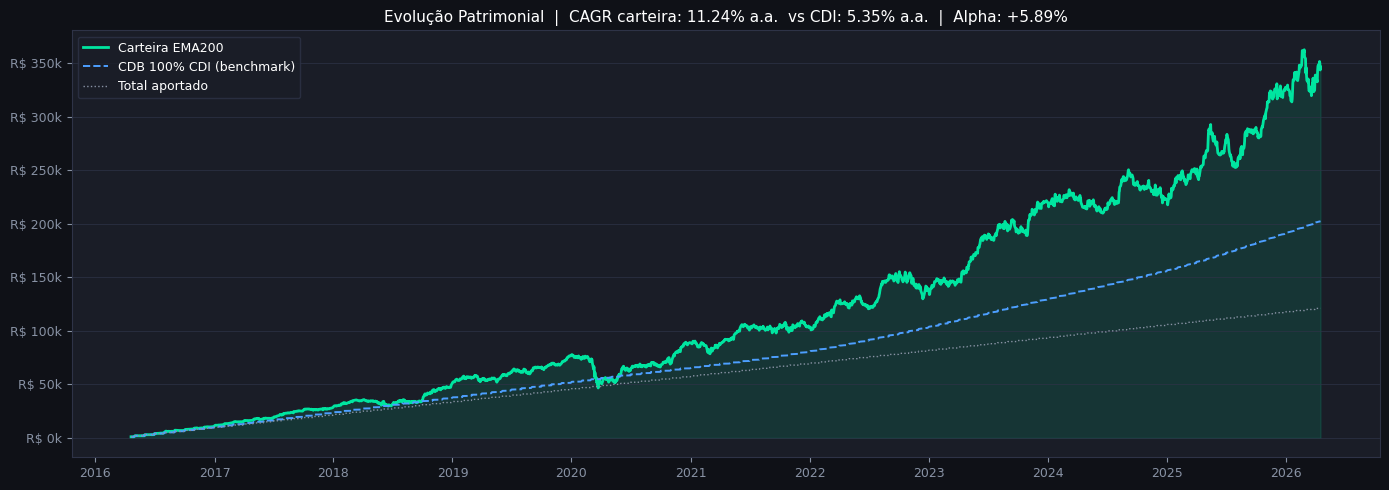

In [ ]:
VERDE, AZUL, CINZA, AMARELO = "#00e5a0", "#4d9fff", "#8892a4", "#f5c542"
BG_FIG, BG_AX = "#0f1117", "#1a1d27"

fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG_FIG)
ax.set_facecolor(BG_AX)
ax.tick_params(colors=CINZA, labelsize=9)
ax.spines[:].set_color("#2e3347")

ax.fill_between(df_hist.index, df_hist["patrimonio"] / 1000,
                alpha=0.12, color=VERDE)
ax.plot(df_hist.index, df_hist["patrimonio"] / 1000,
        color=VERDE, lw=2.0, label="Carteira EMA200")
ax.plot(df_hist.index, df_hist["benchmark_cdi"] / 1000,
        color=AZUL, lw=1.4, ls="--", label="CDB 100% CDI (benchmark)")
ax.plot(df_hist.index, df_hist["aportado_total"] / 1000,
        color=CINZA, lw=1.0, ls=":", label="Total aportado")

ax.set_title(
    f"Evolução Patrimonial  |  CAGR carteira: {cagr_cart:.2f}% a.a.  "
    f"vs CDI: {cagr_bm:.2f}% a.a.  |  Alpha: {cagr_cart - cagr_bm:+.2f}%",
    color="white", fontsize=11
)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}k"))
ax.legend(facecolor=BG_AX, labelcolor="white",
          fontsize=9, edgecolor="#2e3347")
ax.grid(axis="y", color="#2e3347", lw=0.5)
plt.tight_layout()
plt.savefig("chart1_patrimonio.png", dpi=150,
            bbox_inches="tight", facecolor=BG_FIG)
plt.show()

## 📊 Célula 9 — Gráfico 2: Composição do patrimônio (Ações vs CDB)

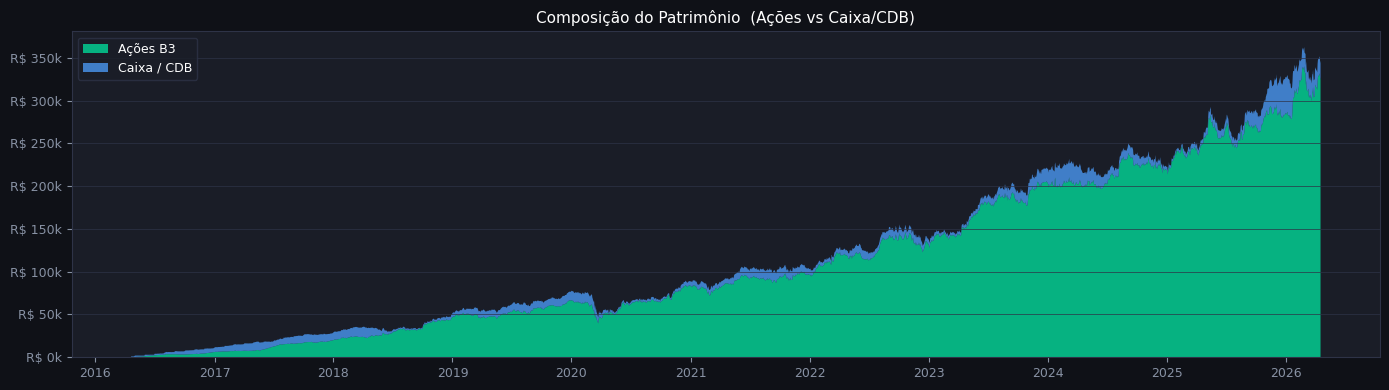

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4), facecolor=BG_FIG)
ax.set_facecolor(BG_AX)
ax.tick_params(colors=CINZA, labelsize=9)
ax.spines[:].set_color("#2e3347")

ax.stackplot(
    df_hist.index,
    df_hist["acoes"] / 1000,
    df_hist["cdb"]   / 1000,
    labels=["Ações B3", "Caixa / CDB"],
    colors=[VERDE, AZUL], alpha=0.75
)

ax.set_title("Composição do Patrimônio  (Ações vs Caixa/CDB)",
             color="white", fontsize=11)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}k"))
ax.legend(facecolor=BG_AX, labelcolor="white",
          fontsize=9, edgecolor="#2e3347", loc="upper left")
ax.grid(axis="y", color="#2e3347", lw=0.5)
plt.tight_layout()
plt.savefig("chart2_composicao.png", dpi=150,
            bbox_inches="tight", facecolor=BG_FIG)
plt.show()

## 📉 Célula 10 — Gráfico 3: Drawdown histórico da carteira

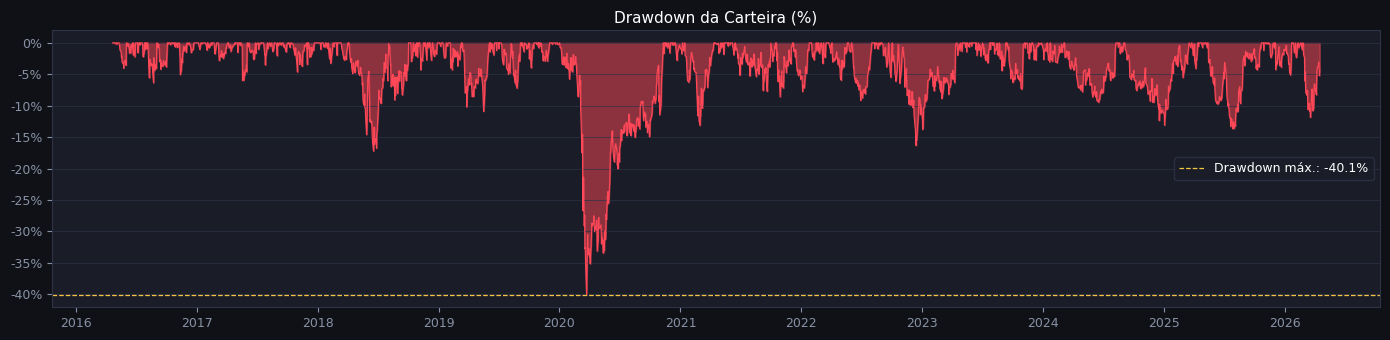

In [ ]:
fig, ax = plt.subplots(figsize=(14, 3.5), facecolor=BG_FIG)
ax.set_facecolor(BG_AX)
ax.tick_params(colors=CINZA, labelsize=9)
ax.spines[:].set_color("#2e3347")

ax.fill_between(df_hist.index, drawdown_d, 0,
                color="#ff4757", alpha=0.5)
ax.plot(df_hist.index, drawdown_d,
        color="#ff4757", lw=0.8)
ax.axhline(max_dd, color=AMARELO, lw=0.9, ls="--",
           label=f"Drawdown máx.: {max_dd:.1f}%")

ax.set_title("Drawdown da Carteira (%)", color="white", fontsize=11)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.legend(facecolor=BG_AX, labelcolor="white",
          fontsize=9, edgecolor="#2e3347")
ax.grid(axis="y", color="#2e3347", lw=0.5)
plt.tight_layout()
plt.savefig("chart3_drawdown.png", dpi=150,
            bbox_inches="tight", facecolor=BG_FIG)
plt.show()

## 🗂️ Célula 11 — Relatório de posição final por ativo

In [ ]:
ultima_data = df_precos.index[-1]

rows = []
for tk in TICKERS:
    preco_atual  = df_precos.loc[ultima_data, tk]
    val_acoes    = cotas[tk] * preco_atual
    provento_tk  = prov_total.get(tk, 0.0)
    pct_carteira = val_acoes / df_hist["acoes"].iloc[-1] * 100 if df_hist["acoes"].iloc[-1] > 0 else 0

    rows.append({
        "Ativo"             : tk.replace(".SA", ""),
        "Cotas"             : round(cotas[tk], 4),
        "Preço atual (R$)"  : round(preco_atual, 2),
        "Valor ações (R$)"  : round(val_acoes, 2),
        "Caixa/CDB (R$)"    : round(caixa[tk], 2),
        "Total ativo (R$)"  : round(val_acoes + caixa[tk], 2),
        "Proventos reinv. (R$)": round(provento_tk, 2),
        "% do patrimônio em ações": f"{pct_carteira:.1f}%",
    })

df_relatorio = pd.DataFrame(rows).set_index("Ativo")

print(f"\nPosição final em {ultima_data.date()}\n")
print(df_relatorio.to_string())
print(f"\nTotal proventos reinvestidos: R$ {prov_total_geral:,.2f}")
print(f"Total patrimônio final      : R$ {pat_final:,.2f}")
df_relatorio


Posição final em 2026-04-17

            Cotas  Preço atual (R$)  Valor ações (R$)  Caixa/CDB (R$)  Total ativo (R$)  Proventos reinv. (R$) % do patrimônio em ações
Ativo                                                                                                                                  
ITSA4   5097.4760             14.81          75493.62        11565.83          87059.45               19058.07                    24.2%
TAEE11  1743.2028             45.01          78461.55         5559.38          84020.93               26928.19                    25.1%
BBAS3   2531.3687             24.40          61765.40         1297.05          63062.44               17163.61                    19.8%
WEGE3   1985.5830             48.65          96598.61         5500.63         102099.25                9444.24                    30.9%

Total proventos reinvestidos: R$ 72,594.11
Total patrimônio final      : R$ 336,242.07


,Cotas,Preço atual (R$),Valor ações (R$),Caixa/CDB (R$),Total ativo (R$),Proventos reinv. (R$),% do patrimônio em ações
Ativo,,,,,,,
ITSA4,5097.4760,14.81,75493.62,11565.83,87059.45,19058.07,24.2%
TAEE11,1743.2028,45.01,78461.55,5559.38,84020.93,26928.19,25.1%
BBAS3,2531.3687,24.40,61765.40,1297.05,63062.44,17163.61,19.8%
WEGE3,1985.5830,48.65,96598.61,5500.63,102099.25,9444.24,30.9%


## 💾 Célula 12 — Exportar histórico para CSV

> Salva o histórico diário completo em CSV para análises externas.

In [ ]:
nome_arquivo = "backtest_historico.csv"

df_export = df_hist.copy()
df_export.columns = [
    "patrimonio_total", "valor_acoes",
    "valor_cdb", "total_aportado", "benchmark_cdi"
]
df_export["retorno_vs_aportado_%"] = (
    (df_export["patrimonio_total"] / df_export["total_aportado"] - 1) * 100
).round(2)

df_export.to_csv(nome_arquivo, sep=";", decimal=",", float_format="%.2f")

print(f"✅ Histórico exportado para: {nome_arquivo}")
print(f"   Linhas: {len(df_export)} | Colunas: {list(df_export.columns)}")

# No Google Colab, faz download automático
try:
    from google.colab import files
    files.download(nome_arquivo)
    print("   Download iniciado automaticamente (Colab)")
except ImportError:
    print(f"   Arquivo salvo localmente: {nome_arquivo}")